# 06C — Entity Sentiment Inference and Evaluation

Model: the roberta-large classifier from 06B (`positive` / `negative` / `mixed_or_unclear` AI impact on a target entity), with the same entity-conditioned input format used in training.

`pipeline/s40_sentiment.py`:

- scores every (entity, block) pair for company, technology, government and person entities with ≥ 10 documents, capped at a random 3,000 pairs per entity (sampling weights kept);
- the context is a 1,400-character window around the mention;
- **test set**: one pair per entity from pairs never used in 06A/06B, 375 per type, labeled by the LLM with the 06A prompt;
- **labeler drift**: 300 items from the 06B validation split relabeled with the same prompt, to compare the current and the original labeling model.

Outputs in `results/sentiment/`: `predictions.parquet`, `test_metrics.json`, `sentiment_test_llm.jsonl`.

In [1]:
import os, sys

PROJECT_DIR = "/content/drive/MyDrive/NLP/NLP_FINAL_PROJECT_Tom_Chen"
IN_COLAB = os.path.isdir("/content")
if IN_COLAB and not os.path.isdir("/content/drive/MyDrive"):
    from google.colab import drive
    drive.mount("/content/drive")
os.environ.setdefault("PROJECT_DIR", PROJECT_DIR)
if IN_COLAB and "DEEPSEEK_API_KEY" not in os.environ:
    from google.colab import userdata
    os.environ["DEEPSEEK_API_KEY"] = userdata.get("DEEPSEEK_API_KEY").strip()
# Path to a checkout of this repository (on Drive in Colab).
sys.path.insert(0, os.environ.get("REPO_DIR", f"{os.environ['PROJECT_DIR']}/code"))

import json
import pandas as pd
from pipeline import config

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)

In [2]:
RUN = False  # set True to re-score (A100 ~15 min) and relabel the test set (~1,800 LLM calls)
if RUN:
    from pipeline import s40_sentiment
    s40_sentiment.main()

## Held-out evaluation

In [3]:
m = json.load(open(config.out("sentiment", "test_metrics.json")))
print(f"test pairs: {m['n_test']:,}   macro-F1: {m['macro_f1']:.3f}")
print("macro-F1 by entity type:", {k: round(v, 3) for k, v in m["macro_f1_by_type"].items()})
print("labeler drift:", m["labeler_drift"])
pd.DataFrame(m["report"]).T.round(3)

test pairs: 1,500   macro-F1: 0.746
macro-F1 by entity type: {'company': 0.74, 'technology': 0.783, 'government_institution': 0.693, 'person': 0.747}
labeler drift: {'n': 300, 'agreement': 0.8633333333333333, 'cohen_kappa': 0.7492047956936628}


,precision,recall,f1-score,support
positive,0.882,0.849,0.865,775.000
negative,0.546,0.845,0.663,155.000
mixed_or_unclear,0.749,0.675,0.710,570.000
accuracy,0.783,0.783,0.783,0.783
macro avg,0.726,0.790,0.746,1500.000
weighted avg,0.797,0.783,0.785,1500.000


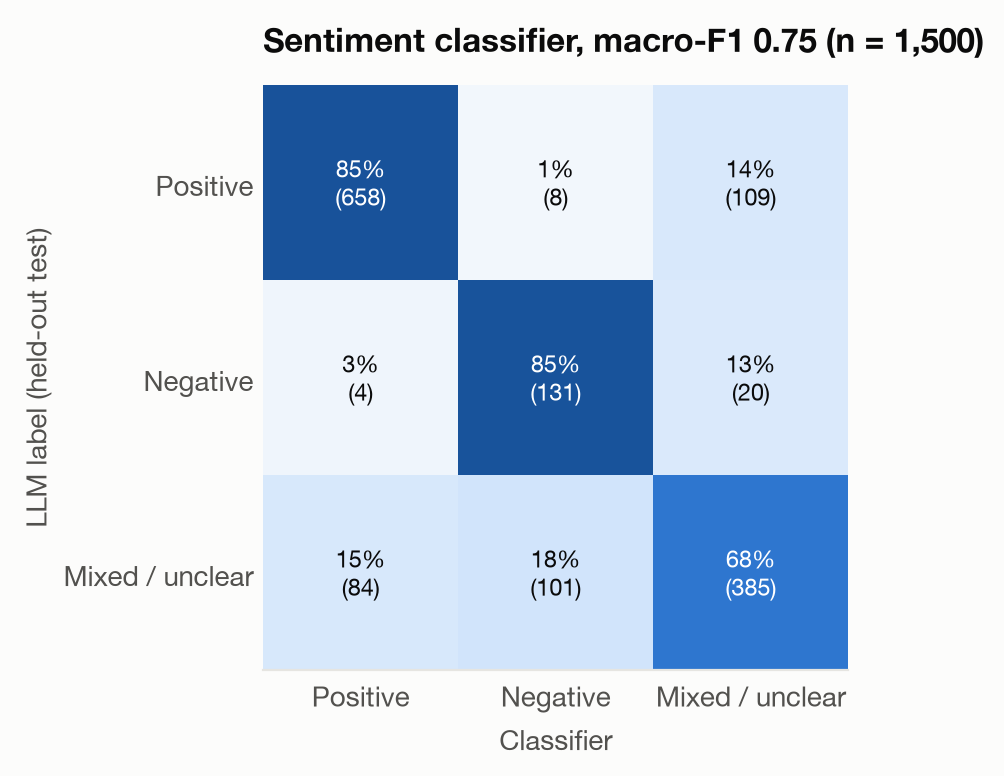

In [4]:
from IPython.display import Image
Image(filename=str(config.out("figures", "f13_sentiment_confusion.png")), width=460)

## Predictions

In [5]:
pred = pd.read_parquet(config.out("sentiment", "predictions.parquet"),
                       columns=["entity_id", "name", "type", "doc_id", "pred", "p_positive", "p_negative", "sample_weight"])
print(f"pairs scored: {len(pred):,} over {pred.entity_id.nunique():,} entities")
pred.pred.value_counts(normalize=True).round(3).to_frame("share")

pairs scored: 502,427 over 6,657 entities


,share
pred,
positive,0.540
mixed_or_unclear,0.309
negative,0.151


In [6]:
pred.groupby("type").agg(pairs=("doc_id", "size"), entities=("entity_id", "nunique"),
                         share_positive=("pred", lambda s: (s == "positive").mean()),
                         share_negative=("pred", lambda s: (s == "negative").mean())).round(3)

,pairs,entities,share_positive,share_negative
type,,,,
company,192679,2141,0.581,0.127
government_institution,31665,424,0.305,0.193
person,78648,1566,0.357,0.238
technology,199435,2526,0.610,0.133
